In [7]:
#Clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load prepared customer features
customer_features = pd.read_csv('customer_features_prepared.csv')
print(f"Loaded customer features: {customer_features.shape}")

Loaded customer features: (121112, 26)


In [9]:
# ============================================================================
# STEP 4.1: Feature Selection for Clustering
# ============================================================================

print("\n[STEP 4.1] Selecting features for clustering...")

# Define clustering features (remove highly correlated and redundant features)
clustering_features = [
    # RFM Core
    'recency_days',
    'CD_TICKET_UNIQUE_total_transactions',
    'MT_TTC_NET_total_spend',
    
    # Behavioral
    'avg_basket_value',
    'transactions_per_month',
    'customer_lifetime_days',
    
    # Product preferences
    'LB_METIER_dept_diversity',
    'product_diversity_score',
    
    # Promotional behavior
    'promo_percentage',
    
    # Store behavior
    'store_loyalty_score',
    
    # Quantity patterns
    'unit_weight_ratio'
]

# Filter features that exist in dataframe
clustering_features = [f for f in clustering_features if f in customer_features.columns]

print(f"Selected {len(clustering_features)} features for clustering:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i}. {feat}")

# Create clustering dataset
df_clustering = customer_features[['NO_TOKEN_CB'] + clustering_features].copy()

# Handle missing values
print(f"\nMissing values before imputation:\n{df_clustering[clustering_features].isnull().sum()}")
df_clustering[clustering_features] = df_clustering[clustering_features].fillna(
    df_clustering[clustering_features].median()
)

# Handle infinite values
df_clustering[clustering_features] = df_clustering[clustering_features].replace(
    [np.inf, -np.inf], np.nan
).fillna(df_clustering[clustering_features].median())

print(f"✓ Clustering dataset prepared: {df_clustering.shape}")


[STEP 4.1] Selecting features for clustering...
Selected 11 features for clustering:
  1. recency_days
  2. CD_TICKET_UNIQUE_total_transactions
  3. MT_TTC_NET_total_spend
  4. avg_basket_value
  5. transactions_per_month
  6. customer_lifetime_days
  7. LB_METIER_dept_diversity
  8. product_diversity_score
  9. promo_percentage
  10. store_loyalty_score
  11. unit_weight_ratio

Missing values before imputation:
recency_days                           0
CD_TICKET_UNIQUE_total_transactions    0
MT_TTC_NET_total_spend                 0
avg_basket_value                       0
transactions_per_month                 0
customer_lifetime_days                 0
LB_METIER_dept_diversity               0
product_diversity_score                0
promo_percentage                       0
store_loyalty_score                    0
unit_weight_ratio                      0
dtype: int64
✓ Clustering dataset prepared: (121112, 12)


In [10]:
# ============================================================================
# STEP 4.2: Feature Scaling
# ============================================================================

print("\n[STEP 4.2] Scaling features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering[clustering_features])

print(f"✓ Features scaled using StandardScaler")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")


[STEP 4.2] Scaling features...
✓ Features scaled using StandardScaler
  Shape: (121112, 11)
  Mean: 0.000000
  Std: 1.000000


In [11]:
# ============================================================================
# PART 5: K-MEANS CLUSTERING
# ============================================================================

print("\n" + "=" * 80)
print("PART 5: K-MEANS CLUSTERING")
print("=" * 80)



PART 5: K-MEANS CLUSTERING



[STEP 5.1] Determining optimal number of clusters...
Donesting k=2... 
Donesting k=3... 
Donesting k=4... 
Donesting k=5... 
Donesting k=6... 
Donesting k=7... 
Donesting k=8... 
Donesting k=9... 
Donesting k=10... 


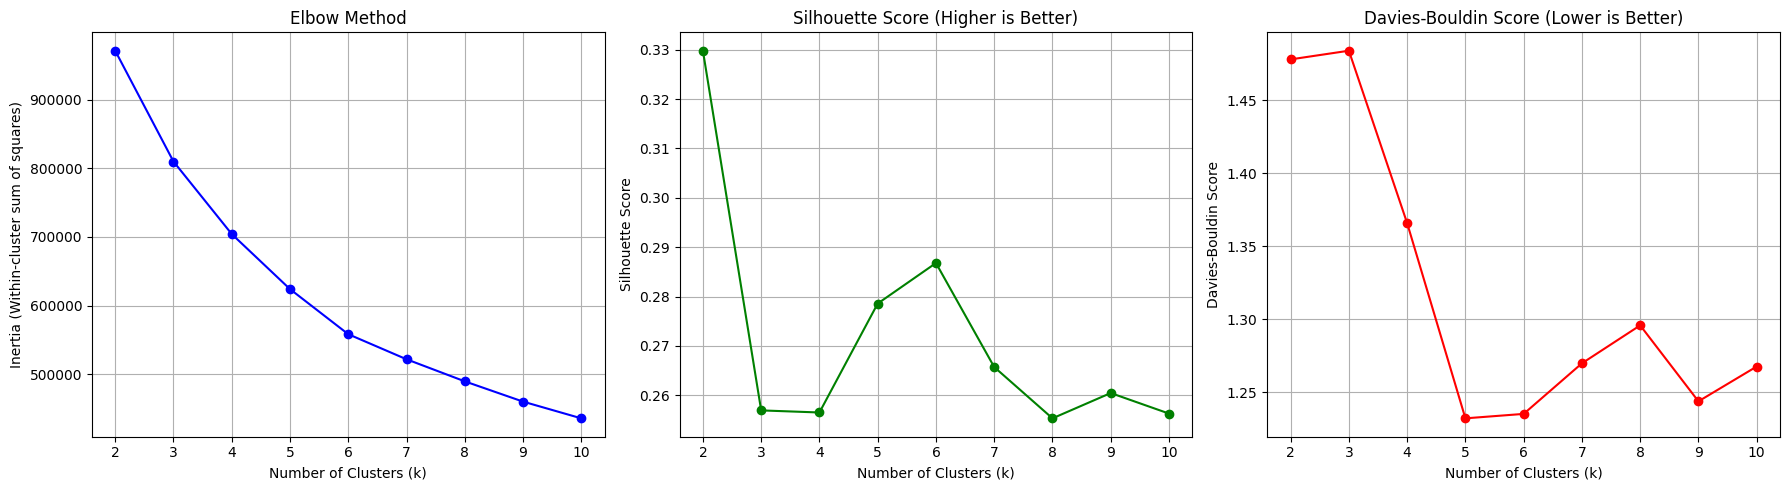


✓ Clustering metrics saved as 'clustering_metrics.png'

Recommended number of clusters:
  Based on Silhouette Score: k=2 (score: 0.330)
  Based on Davies-Bouldin Score: k=5 (score: 1.232)


In [12]:
# ============================================================================
# STEP 5.1: Determine Optimal Number of Clusters
# ============================================================================

print("\n[STEP 5.1] Determining optimal number of clusters...")

# Test range of k values
k_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_range:
    print(f"  Testing k={k}...", end=' ')
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    print("Done")

# Plot elbow curve and metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

# Silhouette score (higher is better)
axes[1].plot(k_range, silhouette_scores, 'go-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(True)

# Davies-Bouldin score (lower is better)
axes[2].plot(k_range, davies_bouldin_scores, 'ro-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].grid(True)

plt.tight_layout()
plt.show()
plt.savefig('clustering_metrics.png', dpi=300, bbox_inches='tight')
print("\n✓ Clustering metrics saved as 'clustering_metrics.png'")
plt.close()

# Recommend optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_db = k_range[np.argmin(davies_bouldin_scores)]

print(f"\nRecommended number of clusters:")
print(f"  Based on Silhouette Score: k={optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"  Based on Davies-Bouldin Score: k={optimal_k_db} (score: {min(davies_bouldin_scores):.3f})")


In [14]:
# ============================================================================
# STEP 5.2: Final Clustering with Optimal K
# ============================================================================

# Choose optimal k (you can adjust this based on business requirements)
optimal_k = 5  # Typically 4-6 segments work well for retail

print(f"\n[STEP 5.2] Performing final clustering with k={optimal_k}...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
df_clustering['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✓ Clustering complete")
print(f"  Silhouette Score: {silhouette_score(X_scaled, df_clustering['Cluster']):.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_score(X_scaled, df_clustering['Cluster']):.3f}")

# Cluster size distribution
print(f"\nCluster distribution:")
print(df_clustering['Cluster'].value_counts().sort_index())
print(f"\nCluster percentages:")
print(df_clustering['Cluster'].value_counts(normalize=True).sort_index() * 100)


[STEP 5.2] Performing final clustering with k=5...
✓ Clustering complete
  Silhouette Score: 0.279
  Davies-Bouldin Score: 1.232

Cluster distribution:
Cluster
0     6367
1    52156
2    15699
3    13218
4    33672
Name: count, dtype: int64

Cluster percentages:
Cluster
0     5.257117
1    43.064271
2    12.962382
3    10.913865
4    27.802365
Name: proportion, dtype: float64



[STEP 5.3] Creating PCA visualization...


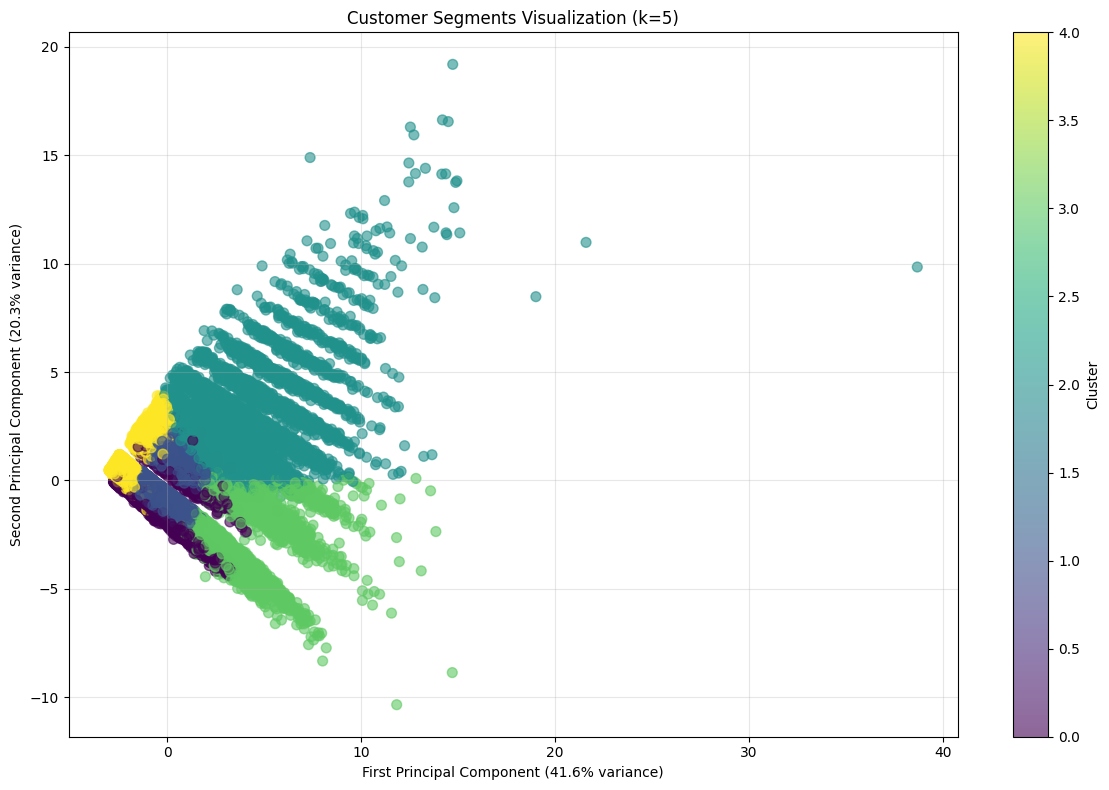

✓ PCA visualization saved as 'cluster_visualization_pca.png'

PCA explained variance: 61.9%


In [15]:
# ============================================================================
# STEP 5.3: PCA Visualization
# ============================================================================

print("\n[STEP 5.3] Creating PCA visualization...")

# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_clustering['Cluster'], 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=50)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'Customer Segments Visualization (k={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('cluster_visualization_pca.png', dpi=300, bbox_inches='tight')
print("✓ PCA visualization saved as 'cluster_visualization_pca.png'")
plt.close()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_[:2].sum():.1%}")

In [16]:
# ============================================================================
# PART 6: SEGMENT CHARACTERIZATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 6: SEGMENT CHARACTERIZATION")
print("=" * 80)

# Merge clusters back to original features
customer_segments = customer_features.merge(
    df_clustering[['NO_TOKEN_CB', 'Cluster']], 
    on='NO_TOKEN_CB'
)


PART 6: SEGMENT CHARACTERIZATION


In [17]:
# ============================================================================
# STEP 6.1: Statistical Segment Profiles
# ============================================================================

print("\n[STEP 6.1] Creating segment profiles...")

# Key metrics for profiling
profile_metrics = [
    'recency_days',
    'CD_TICKET_UNIQUE_total_transactions',
    'MT_TTC_NET_total_spend',
    'avg_basket_value',
    'transactions_per_month',
    'promo_percentage',
    'LB_METIER_dept_diversity',
    'ID_MAGASIN_stores_visited',
    'store_loyalty_score'
]

# Filter available metrics
profile_metrics = [m for m in profile_metrics if m in customer_segments.columns]

# Create segment profiles
segment_profiles = customer_segments.groupby('Cluster')[profile_metrics].mean()

print("\nSegment Profiles (Mean values):")
print("=" * 100)
print(segment_profiles.round(2))

# Save to CSV
segment_profiles.to_csv('segment_profiles.csv')
print("\n✓ Segment profiles saved to 'segment_profiles.csv'")


[STEP 6.1] Creating segment profiles...

Segment Profiles (Mean values):
         recency_days  CD_TICKET_UNIQUE_total_transactions  \
Cluster                                                      
0               17.22                                 1.13   
1                9.05                                 1.17   
2                4.03                                 3.25   
3                6.83                                 1.33   
4                9.39                                 1.10   

         MT_TTC_NET_total_spend  avg_basket_value  transactions_per_month  \
Cluster                                                                     
0                         34.81             31.42                    1.08   
1                         27.85             25.00                    1.11   
2                         76.34             24.87                    2.23   
3                        104.19             82.07                    1.20   
4                         14.


[STEP 6.2] Characterizing segments...


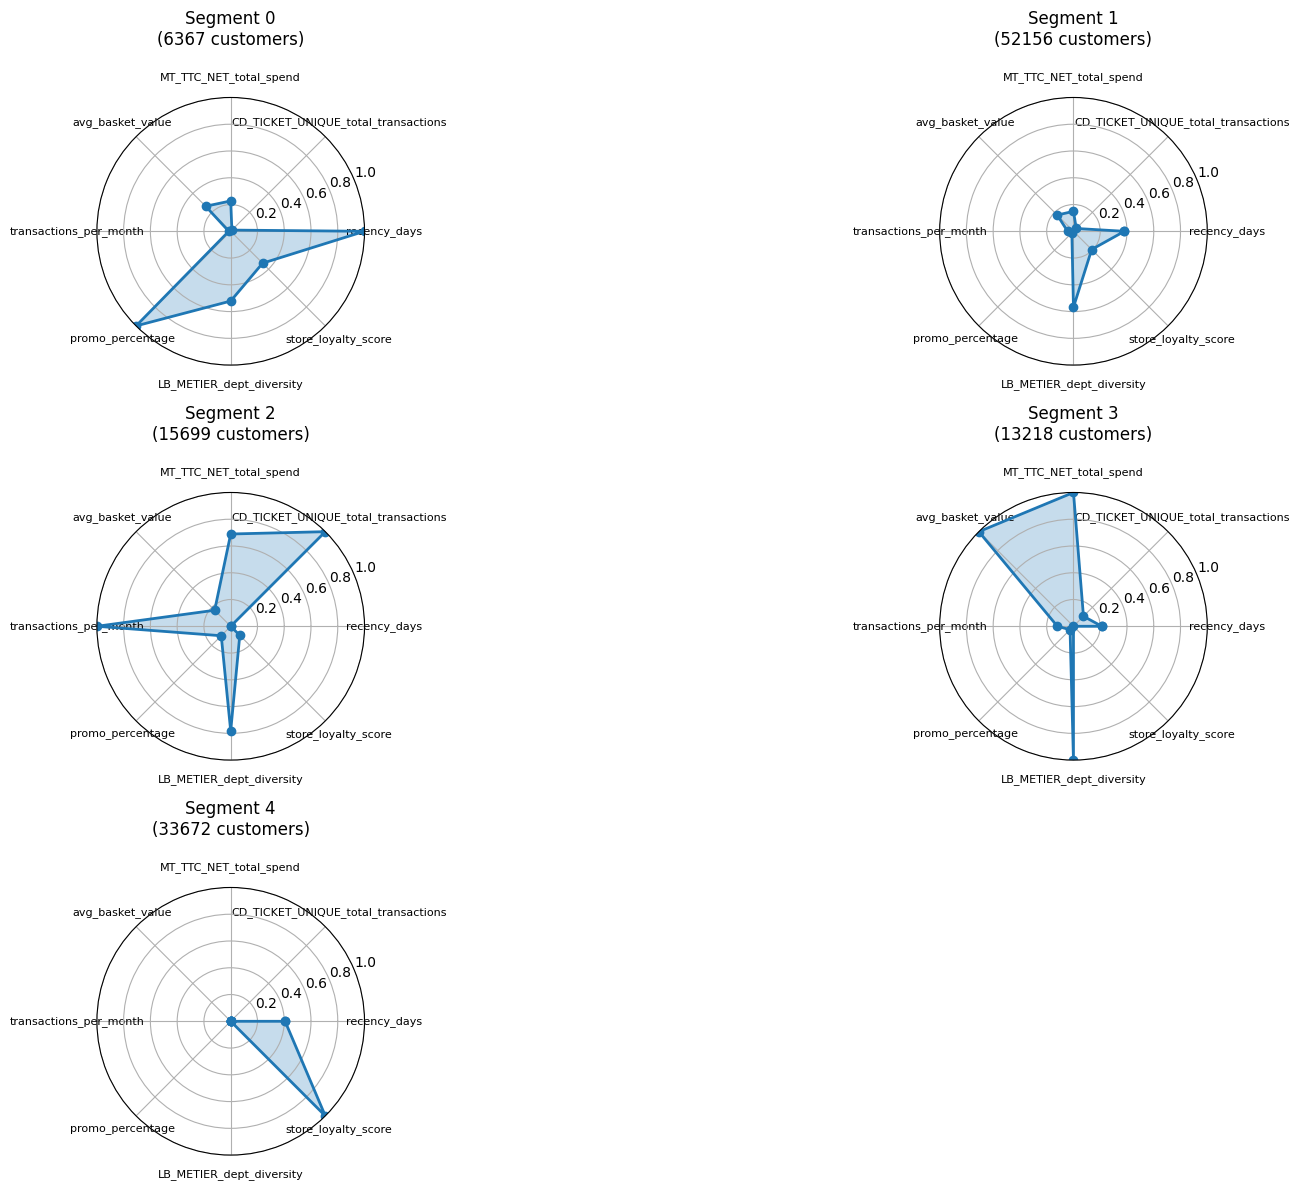

✓ Segment radar charts saved as 'segment_radar_charts.png'


In [18]:
# ============================================================================
# STEP 6.2: Segment Naming and Characterization
# ============================================================================

print("\n[STEP 6.2] Characterizing segments...")

# Create radar charts for each segment
angles = np.linspace(0, 2 * np.pi, len(profile_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(3,2 , figsize=(18, 12), subplot_kw=dict(projection='polar'))
axes = axes.ravel()

for cluster_id in range(optimal_k):
    ax = axes[cluster_id]
    
    # Get normalized values for this cluster
    values = segment_profiles.loc[cluster_id].values
    values_normalized = (values - segment_profiles.min()) / (segment_profiles.max() - segment_profiles.min())
    values_normalized = values_normalized.tolist()
    values_normalized += values_normalized[:1]
    
    # Plot
    ax.plot(angles, values_normalized, 'o-', linewidth=2)
    ax.fill(angles, values_normalized, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(profile_metrics, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Segment {cluster_id}\n({(df_clustering["Cluster"]==cluster_id).sum()} customers)', 
                 size=12, pad=20)
    ax.grid(True)

# Remove extra subplot
if optimal_k < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
plt.savefig('segment_radar_charts.png', dpi=300, bbox_inches='tight')
print("✓ Segment radar charts saved as 'segment_radar_charts.png'")
plt.close()

In [19]:
# ============================================================================
# STEP 6.3: Business Insights Summary
# ============================================================================

print("\n[STEP 6.3] Generating business insights...")

# Calculate segment sizes and values
segment_summary = customer_segments.groupby('Cluster').agg({
    'NO_TOKEN_CB': 'count',
    'MT_TTC_NET_total_spend': ['sum', 'mean'],
    'CD_TICKET_UNIQUE_total_transactions': 'mean',
    'recency_days': 'mean',
    'promo_percentage': 'mean',
    'store_loyalty_score': 'mean'
}).round(2)

segment_summary.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Revenue_Per_Customer',
                          'Avg_Transactions', 'Avg_Recency', 'Avg_Promo_%', 'Avg_Store_Loyalty']

# Calculate revenue contribution
segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100
).round(2)

print("\nSegment Business Summary:")
print("=" * 120)
print(segment_summary)

# Save results
segment_summary.to_csv('segment_business_summary.csv')
customer_segments.to_csv('customers_with_segments.csv', index=False)

print("\n✓ Business summary saved to 'segment_business_summary.csv'")
print("✓ Customer segments saved to 'customers_with_segments.csv'")


[STEP 6.3] Generating business insights...

Segment Business Summary:
         Customer_Count  Total_Revenue  Avg_Revenue_Per_Customer  \
Cluster                                                            
0                  6367      221621.07                     34.81   
1                 52156     1452493.27                     27.85   
2                 15699     1198455.49                     76.34   
3                 13218     1377123.68                    104.19   
4                 33672      486919.14                     14.46   

         Avg_Transactions  Avg_Recency  Avg_Promo_%  Avg_Store_Loyalty  \
Cluster                                                                  
0                    1.13        17.22        87.66               0.54   
1                    1.17         9.05         4.26               0.44   
2                    3.25         4.03        11.29               0.37   
3                    1.33         6.83         5.87               0.31   
4       

In [20]:
print("\n" + "=" * 80)
print("CLUSTERING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nSegments created: {optimal_k}")
print(f"Total customers segmented: {len(customer_segments)}")
print("\nKey outputs generated:")
print("  1. feature_distributions.png")
print("  2. correlation_matrix.png")
print("  3. rfm_analysis.png")
print("  4. clustering_metrics.png")
print("  5. cluster_visualization_pca.png")
print("  6. segment_radar_charts.png")
print("  7. segment_profiles.csv")
print("  8. segment_business_summary.csv")
print("  9. customers_with_segments.csv")
print("\nProceeding to association rules and recommendations!")


CLUSTERING ANALYSIS COMPLETE!

Segments created: 5
Total customers segmented: 121112

Key outputs generated:
  1. feature_distributions.png
  2. correlation_matrix.png
  3. rfm_analysis.png
  4. clustering_metrics.png
  5. cluster_visualization_pca.png
  6. segment_radar_charts.png
  7. segment_profiles.csv
  8. segment_business_summary.csv
  9. customers_with_segments.csv

Proceeding to association rules and recommendations!
